In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import re
from collections import Counter
import random
from tqdm import tqdm
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk
import time
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Loading the Dataset**

This cell loads the dataset from a pickle file named `train.csv`, which contains the training data for title generation. Each example is a dictionary with 'article' and 'title' keys.


In [ ]:
start_time = time.time()
train_path = "/content/drive/MyDrive/Dataset/train.csv"
test_path = "/content/drive/MyDrive/Dataset/test.csv"

print("Loading datasets...")
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Datasets loaded successfully!")

end_time = time.time()
print(f"load dataset time: {end_time - start_time:.2f} seconds")

Loading datasets...
Datasets loaded successfully!
load dataset time: 11.99 seconds


###  Splitting the Training Data into Train and Validation Sets

This cell extracts 500 random samples from the `train_df` DataFrame to create a **validation set**, which will be used later to evaluate the model during training. The `random_state=42` ensures reproducibility of the split. After sampling, the selected rows are removed from the original training set (`train_df`) to prevent data leakage. The final sizes of both the updated training set and the new validation set are then printed.


In [ ]:
start_time = time.time()
print("\nExtracting 500 articles for validation set...")
validation_df = train_df.sample(n=500, random_state=42)
train_df = train_df.drop(validation_df.index)

print(f"\nTrain Set Size After Splitting: {train_df.shape[0]} articles")
print(f"Validation Set Size: {validation_df.shape[0]} articles")
end_time = time.time()
print(f"Load Dataset time: {end_time - start_time:.2f} seconds")


Extracting 500 articles for validation set...

Train Set Size After Splitting: 13379 articles
Validation Set Size: 500 articles
Load Dataset time: 0.01 seconds


###  Exploring Dataset Columns and Checking for Missing Values

This cell performs an initial inspection of the datasets:
- Displays the column names for the training and test datasets.
- Checks for **missing (null) values** in the training, validation, and test datasets using `isnull().sum()`.
- Optionally displays a few sample rows from the training set that contain missing values, if any.
This step helps ensure the datasets are clean and identifies any necessary preprocessing steps related to missing data.


In [ ]:
# Display column names
print(" Columns in Train Dataset:")
print(train_df.columns.tolist())

print("\n Columns in Test Dataset:")
print(test_df.columns.tolist())

# Check for missing values
print("\n Checking for missing/null values in Train Dataset:")
print(train_df.isnull().sum())

print("\n Checking for missing/null values in Validation Dataset:")
print(validation_df.isnull().sum())

print("\n Checking for missing/null values in Test Dataset:")
print(test_df.isnull().sum())

print("\n Sample rows with missing values in train:")
print(train_df[train_df.isnull().any(axis=1)].head())

print("\n Column info and missing value check completed.")

 Columns in Train Dataset:
['title', 'text']

 Columns in Test Dataset:
['title', 'text']

 Checking for missing/null values in Train Dataset:
title    0
text     0
dtype: int64

 Checking for missing/null values in Validation Dataset:
title    0
text     0
dtype: int64

 Checking for missing/null values in Test Dataset:
title    0
text     0
dtype: int64

 Sample rows with missing values in train:
Empty DataFrame
Columns: [title, text]
Index: []

 Column info and missing value check completed.


###  Initializing Text Preprocessing Tools

This cell initializes tools for text preprocessing:
- Creates an instance of **`WordNetLemmatizer`**, which will be used to reduce words to their base (lemma) form.
- Loads a set of **English stopwords** from NLTK, which are common words (like "is", "the", "and") that are usually removed in text processing to reduce noise.
Note: The lemmatizer is initialized twice, which is redundant and can be safely removed without affecting functionality.


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

###  Text Preprocessing Function

This function `preprocess_text(text)` performs a series of cleaning and normalization steps on raw input text:
1. **Missing Value Handling**: If the input is `NaN`, it returns an empty string.
2. **Lowercasing**: Converts all characters to lowercase to maintain consistency.
3. **Non-ASCII Removal**: Replaces newline characters and removes non-ASCII characters to clean the text.
4. **Punctuation Removal**: Uses `str.translate` to eliminate punctuation symbols from the text.
5. **Tokenization**: Splits the text into individual word tokens using `nltk.word_tokenize`.
6. **Stopword Removal**: Filters out common stopwords using the previously loaded list.
7. **Lemmatization**: Reduces words to their base form using the `WordNetLemmatizer`.

The function returns the cleaned and normalized string, ready for further NLP tasks.


In [ ]:
def preprocess_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r"\n", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

###  Combining Title and Text + Preprocessing

This cell performs two major operations:

1. **Combining Title and Text**:
   - It concatenates the `title` and `text` columns into a new column called `combined_text` for the `train_df`, `validation_df`, and `test_df`.
   - This combination ensures that the model can utilize both the article title and its full content during training and evaluation.

2. **Text Preprocessing**:
   - The `combined_text` column in each dataset is processed using the `preprocess_text()` function defined earlier.
   - This cleans and normalizes the text for better performance during modeling.

After processing, the text in all datasets is in a clean and standardized format, suitable for tokenization and training downstream NLP models.


In [ ]:
# Combine title and text into one column
start_time = time.time()
train_df["combined_text"] = train_df["title"] + " " + train_df["text"]
validation_df["combined_text"] = validation_df["title"] + " " + validation_df["text"]
test_df["combined_text"] = test_df["title"] + " " + test_df["text"]

text_column = "combined_text"

print(f" Preprocessing '{text_column}' column in datasets...")

train_df[text_column] = train_df[text_column].apply(preprocess_text)
validation_df[text_column] = validation_df[text_column].apply(preprocess_text)
test_df[text_column] = test_df[text_column].apply(preprocess_text)

print(" All datasets have been preprocessed successfully.")
end_time = time.time()
print(f"Preprocessing: {end_time - start_time:.2f} seconds")


 Preprocessing 'combined_text' column in datasets...
 All datasets have been preprocessed successfully.
Preprocessing: 204.41 seconds


###  Saving Preprocessed Datasets

This cell handles the saving of the cleaned and preprocessed datasets:

1. **File Paths Setup**:
   - It defines the file paths where the preprocessed training, validation, and test sets will be stored.

2. **Saving CSVs**:
   - Each of the DataFrames (`train_df`, `validation_df`, and `test_df`) is saved as a CSV file without the index column.

3. **Logging**:
   - Informative print statements confirm the success of the preprocessing and indicate where the files are saved.

This step ensures that the cleaned datasets can be reloaded later without re-running the entire preprocessing pipeline, improving efficiency for experimentation and training.


In [ ]:
print("Text preprocessing function defined successfully!")

preprocessed_train_path = "/content/preprocessed_train.csv"
preprocessed_validation_path = "/content/preprocessed_validation.csv"
preprocessed_test_path = "/content/preprocessed_test.csv"

print("\nSaving preprocessed datasets...")
train_df.to_csv(preprocessed_train_path, index=False)
validation_df.to_csv(preprocessed_validation_path, index=False)
test_df.to_csv(preprocessed_test_path, index=False)

print("\nPreprocessing completed successfully! Files saved at:")
print(preprocessed_train_path)
print(preprocessed_validation_path)
print(preprocessed_test_path)


Text preprocessing function defined successfully!

Saving preprocessed datasets...

Preprocessing completed successfully! Files saved at:
/content/preprocessed_train.csv
/content/preprocessed_validation.csv
/content/preprocessed_test.csv


###  Device Configuration & Hyperparameters

This cell sets up the computational device and defines important hyperparameters for training the model:

1. **Device Selection**:
   - Uses GPU (`cuda`) if available, otherwise falls back to CPU. This ensures that the code utilizes available hardware acceleration for faster training.

2. **Hyperparameters**:
   - `HIDDEN_DIM`: Number of hidden units in the RNN layers.
   - `BATCH_SIZE`: Number of samples per training batch.
   - `LEARNING_RATE`: Controls the step size of the optimizer during training.
   - `EPOCHS`: Number of full passes over the training data.
   - `MAX_NEW_TOKENS`: Maximum number of tokens the decoder can generate during inference.
   - `DROPOUT`: Regularization technique to prevent overfitting by randomly deactivating neurons.

These settings influence training speed, model capacity, and performance.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters
HIDDEN_DIM = 300
BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 10
MAX_NEW_TOKENS = 40
DROPOUT = 0.2

Using device: cuda


###  Vocabulary Class Definition

This cell defines a custom `Vocabulary` class for managing the mapping between tokens (words) and their corresponding indices. It's essential for preparing text data to be used in neural network models.

#### Key Components:
1. **Special Tokens**:
   - `<pad>`: Padding token for batching.
   - `<bos>`: Beginning-of-sequence token.
   - `<eos>`: End-of-sequence token.
   - `<unk>`: Token for unknown words.

2. **`__init__`**:
   - Initializes the `itos` (index-to-string) and `stoi` (string-to-index) dictionaries.
   - Takes a `freq_threshold` which determines how frequently a word must appear to be included in the vocabulary.

3. **`build_vocabulary`**:
   - Takes a list of sentences and:
     - Counts the frequency of each word.
     - Only includes words that appear in at least `freq_threshold * total_sentences`.
     - Ensures the vocabulary is not cluttered with rare or noisy words.

4. **`numericalize`**:
   - Converts a sentence into a list of token indices based on the vocabulary.
   - Unknown words are mapped to `<unk>`.

This class is essential for converting preprocessed text into numerical format that the model can process.


In [ ]:
class Vocabulary:
    def __init__(self, min_freq=3):
        self.itos = {0: "<pad>", 1: "<bos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.min_freq = min_freq

    def __len__(self):
        return len(self.itos)

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        for sentence in sentence_list:
            for word in sentence.split():
                frequencies[word] += 1

        print(f"Total unique tokens: {len(frequencies)}")

        idx = 4
        for word, freq in frequencies.items():
            if freq >= self.min_freq:
                self.itos[idx] = word
                self.stoi[word] = idx
                idx += 1

        print(f"Final vocabulary size: {len(self.itos)} (including special tokens)")

    def numericalize(self, text):
        tokenized_text = text.split()
        return [
            self.stoi[token] if token in self.stoi else self.stoi["<unk>"]
            for token in tokenized_text
        ]


###  Dataset Class and Collate Function

This section defines the `WikiDataset` class and a custom `collate_fn` to efficiently prepare batches for training and validation.



####  `WikiDataset` Class:
A subclass of `torch.utils.data.Dataset`, used to represent our training/validation dataset.

**Key Components**:
- **Initialization (`__init__`)**:
  - Takes the DataFrame, the vocabulary object, and column names for text and title.
  - Stores the raw (already preprocessed) text and title sequences.

- **`__getitem__`**:
  - For each index, retrieves the `text` and `title`, converts them to numerical format using the vocabulary.
  - Adds `<bos>` and `<eos>` tokens to both `text` and `title`.
  - Returns a dictionary containing tokenized tensors and their lengths.

- **`__len__`**:
  - Returns the number of samples in the dataset.



####  `collate_fn` Function:
Used to merge multiple dataset samples into a single batch for the `DataLoader`.

**Steps**:
1. Sorts the batch by text length in descending order (important for RNN efficiency).
2. Extracts texts, titles, and their respective lengths.
3. Uses `torch.nn.utils.rnn.pad_sequence` to pad texts and titles to the same length across the batch.
4. Moves the padded sequences and length tensors to the appropriate `device`.

This custom function ensures that the batching is handled properly, especially for variable-length sequences commonly found in NLP tasks.


In [ ]:

#  Dataset Class Implementation
class WikiDataset(Dataset):
    def __init__(self, df, vocab, text_column="text", title_column="title"):
        self.df = df
        self.vocab = vocab
        self.texts = df[text_column].tolist()
        self.titles = df[title_column].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = self.texts[idx]
        title = self.titles[idx]

        # Numericalize text and title
        text_numericalized = [self.vocab.stoi["<bos>"]] + self.vocab.numericalize(text) + [self.vocab.stoi["<eos>"]]
        title_numericalized = [self.vocab.stoi["<bos>"]] + self.vocab.numericalize(title) + [self.vocab.stoi["<eos>"]]

        return {
            "text": torch.tensor(text_numericalized, dtype=torch.long),
            "title": torch.tensor(title_numericalized, dtype=torch.long),
            "text_len": len(text_numericalized),
            "title_len": len(title_numericalized)
        }



In [ ]:
# Collate Function for DataLoader
def collate_fn(batch):

    batch.sort(key=lambda x: x["text_len"], reverse=True)

    texts = [item["text"] for item in batch]
    titles = [item["title"] for item in batch]
    text_lens = [item["text_len"] for item in batch]
    title_lens = [item["title_len"] for item in batch]

    # Pad sequences
    texts_padded = torch.nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=0)
    titles_padded = torch.nn.utils.rnn.pad_sequence(titles, batch_first=True, padding_value=0)

    return {
        "text": texts_padded.to(device),
        "title": titles_padded.to(device),
        "text_len": torch.tensor(text_lens, dtype=torch.long).to(device),
        "title_len": torch.tensor(title_lens, dtype=torch.long).to(device)
    }

###  EncoderRNN: Bi-directional GRU Encoder

This class defines the encoder for the sequence-to-sequence model using a **bidirectional GRU**.

---

####  Components:
- `nn.Embedding`: Converts input token indices into dense vector representations.
- `nn.GRU`: A **bidirectional GRU** processes sequences in both forward and backward directions.
- `nn.Linear`: Used to merge the final forward and backward GRU hidden states into a single context vector.
- `nn.Dropout`: Regularization to prevent overfitting.

---

####  `forward()`:
1. **Embedding**: Transforms input tokens into embeddings.
2. **Packing**: Uses `pack_padded_sequence` to ignore padding during GRU computation.
3. **GRU**: Processes the packed sequences bidirectionally.
4. **Hidden State Combination**:
   - Takes the last hidden states from both directions: `hidden[-2,:,:]` (forward) and `hidden[-1,:,:]` (backward).
   - Concatenates them and passes through a linear layer followed by `tanh` to compress into a single vector.


The encoder returns the final **context vector** (shape: `[batch_size, hidden_dim]`), which summarizes the entire input sequence and will be used by the decoder.


In [ ]:
# EncoderRNN Implementation
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, dropout):
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, x_len):

        embedded = self.dropout(self.embedding(x))

        # Pack padded sequence
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, x_len.cpu(), batch_first=True, enforce_sorted=True
        )

        packed_outputs, hidden = self.gru(packed_embedded)
        # hidden shape: (2, batch_size, hidden_dim) - bidirectional

        # Combine bidirectional hidden states
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        # hidden shape: (batch_size, hidden_dim)

        return hidden

###  DecoderRNN: GRU-based Decoder

This class defines the decoder for the sequence-to-sequence model using a **unidirectional GRU**.



####  Components:
- `nn.Embedding`: Converts the current input token index into a dense vector.
- `nn.GRU`: Processes the embedded token and updates the hidden state.
- `nn.Linear`: Maps GRU output to vocabulary size to produce logits for the next token prediction.
- `nn.Dropout`: Regularization applied on the embedding layer.



####  `forward()`:
1. **Embedding**: Transforms the input token (`x`) into an embedding of shape `(batch_size, 1, hidden_dim)`.
2. **GRU**: Takes the embedded input and the current hidden state to produce:
   - `output`: GRU output at the current step (shape: `(batch_size, 1, hidden_dim)`).
   - `hidden`: Updated hidden state for the next time step.
3. **Prediction**: The output is passed through a linear layer to get scores over the vocabulary (`(batch_size, vocab_size)`).



The decoder is typically called **step-by-step** during generation, predicting one token at a time.


In [ ]:
# DecoderRNN Implementation
class DecoderRNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, dropout):
        super(DecoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden):

        embedded = self.dropout(self.embedding(x))  # (batch_size, 1, hidden_dim)

        # GRU expects hidden shape: (1, batch_size, hidden_dim)
        output, hidden = self.gru(embedded, hidden.unsqueeze(0))

        # output shape: (batch_size, 1, hidden_dim)
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden.squeeze(0)

###  Seq2seqRNN: Encoder-Decoder Model

This class ties together the **Encoder** and **Decoder** to form a full sequence-to-sequence architecture.


####  Components:
- `encoder`: A `EncoderRNN` instance that encodes input sequences.
- `decoder`: A `DecoderRNN` instance that generates output sequences.
- `vocab`: Vocabulary object to determine output size and tokens.


####  `forward()`:
1. **Encoding**:
   - The input `text` is encoded using the encoder GRU.
   - The encoder returns a single hidden state combining both directions of the bidirectional GRU.

2. **Decoding (Auto-regressive)**:
   - The first input to the decoder is always the `<bos>` token.
   - For each time step `t` in the output sequence:
     - The decoder predicts the next token.
     - The output is stored in `outputs`.
     - **Teacher forcing** is applied with probability `teacher_forcing_ratio`:
       - With teacher forcing: use the ground truth token from the `title`.
       - Without teacher forcing: use the model’s own predicted token.




In [ ]:
# Seq2seqRNN Implementation
class Seq2seqRNN(nn.Module):
    def __init__(self, encoder, decoder, vocab):
        super(Seq2seqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab = vocab
        self.vocab_size = len(vocab)

    def forward(self, text, title, text_len, teacher_forcing_ratio=0.5):
        # text shape: (batch_size, text_seq_len)
        # title shape: (batch_size, title_seq_len)

        batch_size = title.shape[0]
        title_len = title.shape[1]

        # Encode the input text
        hidden = self.encoder(text, text_len)

        # First input to decoder is <bos> token
        input = title[:, 0]

        # Tensor to store decoder outputs
        outputs = torch.zeros(batch_size, title_len, self.vocab_size).to(device)

        for t in range(1, title_len):
            # Decode one token at a time
            output, hidden = self.decoder(input.unsqueeze(1), hidden)

            # Store predictions
            outputs[:, t] = output

            # Decide whether to use teacher forcing
            teacher_force = random.random() < teacher_forcing_ratio

            # Get the highest predicted token
            top1 = output.argmax(1)

            # Apply teacher forcing or use own prediction
            input = title[:, t] if teacher_force else top1

        return outputs

###  Data Preparation & Model Initialization

1. **Preprocessed Data Loading**:
   - Load cleaned and tokenized training and validation datasets (`.csv` format).

2. **Vocabulary Creation**:
   - Use a frequency threshold (`freq_threshold = 0.01`) to build a vocabulary.
   - The vocabulary covers both the `text` and `title` columns from the training set.

3. **Dataset Construction**:
   - Wrap the data into a custom `WikiDataset` that:
     - Tokenizes and numericalizes the text.
     - Adds `<bos>` and `<eos>` tokens.
     - Returns padded sequences and their lengths.

4. **DataLoader Setup**:
   - Use PyTorch’s `DataLoader` to enable batch loading and shuffling.
   - Apply a `collate_fn` to:
     - Sort by sequence length (for efficient packing).
     - Pad sequences to the same length within a batch.


In [ ]:
# Model Initialization and Data Preparation
# Load preprocessed data

start_data = time.time()
train_df = pd.read_csv("/content/preprocessed_train.csv")
val_df = pd.read_csv("/content/preprocessed_validation.csv")

# Build vocabulary
vocab = Vocabulary(min_freq=3)
vocab.build_vocabulary(train_df["text"].tolist() + train_df["title"].tolist())

# Create datasets
train_dataset = WikiDataset(train_df, vocab)
val_dataset = WikiDataset(val_df, vocab)
end_data = time.time()
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"\nVocab build time: {end_data - start_data:.2f} seconds")

Total unique tokens: 1115578
Final vocabulary size: 302054 (including special tokens)

Vocab build time: 18.18 seconds


In [ ]:
print("Random sample tokens from vocab:")
for i, (word, idx) in enumerate(vocab.stoi.items()):
    print(f"{word}: {idx}")
    if i >= 20:
        break


Random sample tokens from vocab:
<pad>: 0
<bos>: 1
<eos>: 2
<unk>: 3
Port: 4
St.: 5
Lucie: 6
is: 7
a: 8
city: 9
in: 10
County,: 11
Florida,: 12
United: 13
States.: 14
It: 15
the: 16
most: 17
populous: 18
municipality: 19
county: 20


In [ ]:
print(f"Vocabulary size: {len(vocab)}")

print("Sample word-to-index mapping (stoi):")
for word, idx in list(vocab.stoi.items())[:10]:
    print(f"{word}: {idx}")


Vocabulary size: 302054
Sample word-to-index mapping (stoi):
<pad>: 0
<bos>: 1
<eos>: 2
<unk>: 3
Port: 4
St.: 5
Lucie: 6
is: 7
a: 8
city: 9


In [ ]:
print("Sample index-to-word mapping (itos):")
for idx in range(10):
    print(f"{idx}: {vocab.itos[idx]}")


Sample index-to-word mapping (itos):
0: <pad>
1: <bos>
2: <eos>
3: <unk>
4: Port
5: St.
6: Lucie
7: is
8: a
9: city


In [ ]:
import pickle

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


In [ ]:
real_tokens = {k: v for k, v in vocab.stoi.items() if v >= 4}
print(f"Real vocabulary size (excluding special tokens): {len(real_tokens)}")


Real vocabulary size (excluding special tokens): 302050


###  Model Initialization

- **EncoderRNN & DecoderRNN**:
  - Both use the same hidden dimension (`HIDDEN_DIM`) and dropout value (`DROPOUT`).
  - The vocabulary size (`len(vocab)`) is passed to create the embedding layers.

- **Seq2seqRNN Wrapper**:
  - Combines the encoder and decoder into a full sequence-to-sequence architecture.

###  Optimization Setup

- **Adam Optimizer**:
  - Adaptive learning rate optimization for efficient convergence.
  - Initialized with `LEARNING_RATE`.

- **Cross Entropy Loss**:
  - Used for token-level classification.
  - `ignore_index=0`: Ignores padding tokens (`<pad>`) when computing the loss.


In [ ]:
# Initialize models
encoder = EncoderRNN(len(vocab), HIDDEN_DIM, DROPOUT).to(device)
decoder = DecoderRNN(len(vocab), HIDDEN_DIM, DROPOUT).to(device)
model = Seq2seqRNN(encoder, decoder, vocab).to(device)

# Optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=0)

#  Training & Evaluation Loop
 This section contains the training and validation routines for the
 sequence-to-sequence RNN model.

 The `train` function runs one epoch of training:
 - Uses teacher forcing while generating each word in the title.
 - Computes the loss after skipping the <bos> token.
 - Performs backpropagation and applies gradient clipping.

 The `evaluate` function runs on the validation set:
 - No teacher forcing is used here (greedy decoding).
 - Loss is computed similarly to training, for fair comparison.

 The model is trained for `EPOCHS` number of epochs.
 After each epoch, the validation loss is checked.
 If it improves, the model is saved as 'best_model.pt'.




Epoch 1/10


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.01it/s]


Train Loss: 7.261 | Val Loss: 6.584
Model saved!

Epoch 2/10


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.01it/s]


Train Loss: 5.276 | Val Loss: 6.244
Model saved!

Epoch 3/10


...

Train Loss: 1.156 | Val Loss: 6.304

Epoch 9/10


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  2.93it/s]


Train Loss: 0.713 | Val Loss: 6.472

Epoch 10/10


Evaluating: 100%|██████████| 32/32 [00:10<00:00,  3.09it/s]


Train Loss: 0.453 | Val Loss: 6.594

 Total epoch time: 7395.35 seconds


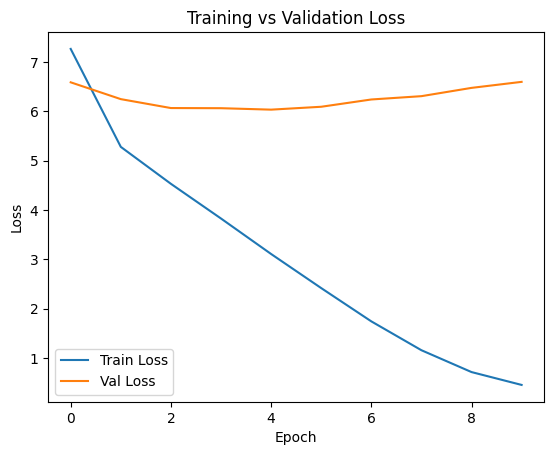

In [ ]:
# Training Loop
def train(model, dataloader, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for batch in tqdm(dataloader, desc="Training"):
        text = batch["text"]
        title = batch["title"]
        text_len = batch["text_len"]

        optimizer.zero_grad()

        output = model(text, title, text_len)

        # Reshape for loss calculation
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        title = title[:, 1:].reshape(-1)

        loss = criterion(output, title)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)
# Validation function
def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            text = batch["text"]
            title = batch["title"]
            text_len = batch["text_len"]

            output = model(text, title, text_len, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            title = title[:, 1:].reshape(-1)

            loss = criterion(output, title)

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)
# Training parameters
CLIP = 1.0
best_valid_loss = float('inf')
train_losses = []
val_losses = []
start_epoch = time.time()
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, val_loader, criterion)
    train_losses.append(train_loss)
    val_losses.append(valid_loss)
    print(f"Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")

    # Save best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pt")
        print("Model saved!")

end_epoch = time.time()
print(f"\n Total epoch time: {end_epoch - start_epoch:.2f} seconds")
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
!pip install rouge

 Define a function to generate titles from input article text using the trained Seq2seq model.
 The function encodes the input text using the encoder and then sequentially generates tokens
 using the decoder until an <eos> token is produced or a maximum token limit is reached.
 The predicted token indices are mapped back to words to form the final generated title.


In [ ]:
from rouge import Rouge
start_time = time.time()
# Generation Function

def generate_title(model, text, text_len, max_new_tokens=MAX_NEW_TOKENS):
    """
    Generate a title for a given input text using the trained Seq2seq model.

    Args:
        model: Trained Seq2seqRNN model.
        text: Tensor of shape (1, seq_len) for the article text.
        text_len: Length of the input text (tensor with a single integer).
        max_new_tokens: Maximum number of tokens to generate.

    Returns:
        Generated title as a string.
    """
    model.eval()
    with torch.no_grad():

        hidden = model.encoder(text, text_len)


        input_token = torch.tensor([model.vocab.stoi["<bos>"]], dtype=torch.long).to(device)
        generated_tokens = []


        for _ in range(max_new_tokens):
            output, hidden = model.decoder(input_token.unsqueeze(1), hidden)

            pred_token = output.argmax(1).item()
            if pred_token == model.vocab.stoi["<eos>"]:
                break
            generated_tokens.append(pred_token)
            input_token = torch.tensor([pred_token], dtype=torch.long).to(device)


    generated_words = [model.vocab.itos[token] for token in generated_tokens]
    return " ".join(generated_words)

####Test Set Evaluation and ROUGE Scoring
This section evaluates the trained model on the preprocessed test set. It loads the best saved model, generates titles for each test example, and compares them to the reference titles. Finally, ROUGE scores are computed to measure the quality of the generated titles against the ground truth.

In [ ]:
# Load preprocessed test set
test_df = pd.read_csv("preprocessed_test.csv")

# Create test dataset
test_dataset = WikiDataset(test_df, vocab, text_column="text", title_column="title")

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))

# Lists to hold the generated titles and ground truth titles
generated_titles = []
reference_titles = []
generation_start = time.time()
print("Generating titles for test set...")
for batch in tqdm(test_loader, desc="Generating"):

    text = batch["text"]
    text_len = batch["text_len"]

    pred_title = generate_title(model, text, text_len)
    generated_titles.append(pred_title)


    ref_tokens = batch["title"][0].tolist()

    ref_tokens = [token for token in ref_tokens if token not in
                  [vocab.stoi["<bos>"], vocab.stoi["<eos>"], vocab.stoi["<pad>"]]]
    ref_title = " ".join([vocab.itos[token] for token in ref_tokens])
    reference_titles.append(ref_title)


    print(f"\nGenerated Title: {pred_title}")
    print(f"Reference Title: {ref_title}")

generation_end = time.time()
print(f"\nTitle generation completed in: {generation_end - generation_start:.2f} seconds")



Generating titles for test set...


Generating:   2%|▏         | 2/100 [00:00<00:06, 14.91it/s]


Generated Title: <unk>
Reference Title: <unk>

Generated Title: Catholic High High School (Little Arkansas)
Reference Title: Catholic High School, Singapore

Generated Title: Texas A&M
Reference Title: Minnesota Golden Gophers


Generating:   6%|▌         | 6/100 [00:00<00:11,  7.86it/s]


Generated Title: List of people from New York (state)
Reference Title: List of people from Louisiana

Generated Title: Villani
Reference Title: Theobald

Generated Title: FC FC
Reference Title: FC Shakhtar Donetsk

Generated Title: <unk> Maryland
Reference Title: Pasadena, Maryland


...


Generated Title: <unk>
Reference Title: <unk> Province

Generated Title: <unk>
Reference Title: <unk> Islands

Generated Title: Shenandoah, Pennsylvania
Reference Title: Dallas, Pennsylvania

Generated Title: <unk> Alabama
Reference Title: Ashford, Alabama


Generating:  98%|█████████▊| 98/100 [00:10<00:00, 12.70it/s]


Generated Title: University University
Reference Title: Kutztown University of Pennsylvania

Generated Title: Paul Sturrock
Reference Title: Bear Bryant

Generated Title: Mark Cueto
Reference Title: Jonathan Spector


Generating: 100%|██████████| 100/100 [00:11<00:00,  8.97it/s]


Generated Title: County Wexford
Reference Title: Abia State

Generated Title: Port Huron, Ohio
Reference Title: Table Rock, Nebraska

Title generation completed in: 11.16 seconds


In [ ]:
rouge_start = time.time()

rouge = Rouge()
scores = rouge.get_scores(generated_titles, reference_titles, avg=True)

rouge_end = time.time()
print(f"ROUGE calculation time: {rouge_end - rouge_start:.2f} seconds")

print("\nROUGE Evaluation Scores:")
print("ROUGE-1 F1:", scores["rouge-1"]["f"])
print("ROUGE-2 F1:", scores["rouge-2"]["f"])
print("ROUGE-L F1:", scores["rouge-l"]["f"])

ROUGE calculation time: 0.01 seconds

ROUGE Evaluation Scores:
ROUGE-1 F1: 0.3243809495349928
ROUGE-2 F1: 0.04499999955712501
ROUGE-L F1: 0.3243809495349928


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
import random
from tqdm import tqdm
import torch



####coderRNN: Bidirectional GRU with GloVe Embedding Support
This class defines the encoder module of the sequence-to-sequence model. It uses a bidirectional GRU to encode input text sequences. The final hidden states from both directions are combined and passed through a linear layer. It also includes an optional method to load pre-trained GloVe embeddings into the embedding layer using the provided vocabulary.

In [ ]:
start_time = time.time()
class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, dropout, vocab=None):
        """
        Args:
            vocab_size: Size of the vocabulary.
            hidden_dim: Dimension of hidden states.
            dropout: Dropout probability.
            vocab: Vocabulary object (to access stoi mapping for loading GloVe).
        """
        super(EncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.vocab = vocab
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, x_len):

        embedded = self.dropout(self.embedding(x))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, x_len.cpu(), batch_first=True, enforce_sorted=True
        )
        packed_outputs, hidden = self.gru(packed_embedded)

        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return hidden

    def load_embeddings(self, glove_path):
        start = time.time()
        """
        Load pre-trained GloVe embeddings from a file and initialize the embedding weights.
        The GloVe file should be in text format with each line: word val1 val2 ... valN.
        """
        print("Loading GloVe embeddings...")
        embeddings_index = {}
        with open(glove_path, 'r', encoding='utf8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                vector = np.asarray(values[1:], dtype='float32')
                embeddings_index[word] = vector

        embedding_dim = self.embedding.embedding_dim
        vocab_size = self.embedding.num_embeddings

        embedding_matrix = np.random.normal(scale=0.6, size=(vocab_size, embedding_dim))


        if self.vocab is not None:
            for word, idx in self.vocab.stoi.items():
                if word in embeddings_index:
                    embedding_matrix[idx] = embeddings_index[word]
        else:
            print("Warning: No vocabulary provided to EncoderRNN. Skipping GloVe loading.")

        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        print("GloVe embeddings loaded.")
        end = time.time()
        print(f"GloVe loading time: {end - start:.2f} seconds")


###Hierarchical Encoder (HierEncoderRNN)
This class implements a hierarchical encoder with two GRUs: one at the word level and one at the sentence level. Although the current setup treats the full text as a single sentence, the structure allows for future expansion to true hierarchical encoding. The model first encodes words, averages them into sentence representations, and then encodes these at the sentence level.

In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import sent_tokenize
start_time = time.time()
class HierEncoderRNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, dropout):
        """
        Hierarchical encoder: first at word-level then at sentence-level.
        For simplicity, this implementation assumes the input text is split into sentences externally.
        """
        super(HierEncoderRNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.word_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.sent_gru = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, x_len):
        """
        Args:
            x: (batch_size, seq_len) numericalized tokens.
            x_len: lengths of the input sequences.

        For a real hierarchical encoder, you would first split each text into sentences.
        Here, for demonstration, we treat the entire text as a single sentence.
        """

        embedded = self.dropout(self.embedding(x))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded, x_len.cpu(), batch_first=True, enforce_sorted=True
        )
        packed_word_outputs, _ = self.word_gru(packed_embedded)
        word_outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_word_outputs, batch_first=True)


        sent_embeddings = torch.mean(word_outputs, dim=1, keepdim=True)


        sent_outputs, hidden_sent = self.sent_gru(sent_embeddings)
        final_hidden = hidden_sent.squeeze(0)
        return final_hidden


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


###Decoder with Stacked GRUs (Decoder2RNN)
This decoder uses two stacked GRU layers to generate tokens one at a time. It takes an input token and the encoder's final hidden state, processes it through two GRUs, and outputs a prediction over the vocabulary. Dropout is applied for regularization, and the second GRU refines the hidden representation from the first.

In [ ]:
start_time = time.time()
class Decoder2RNN(nn.Module):
    def __init__(self, vocab_size, hidden_dim, dropout):
        """
        Decoder with two sequential GRU layers.
        """
        super(Decoder2RNN, self).__init__()
        self.hidden_dim = hidden_dim
        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.gru1 = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.gru2 = nn.GRU(hidden_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden):
        """
        Args:
            x: (batch_size, 1) current input token.
            hidden: (batch_size, hidden_dim) from the encoder.
        """
        embedded = self.dropout(self.embedding(x))

        output1, hidden1 = self.gru1(embedded, hidden.unsqueeze(0))

        output2, hidden2 = self.gru2(output1, hidden.unsqueeze(0))

        prediction = self.fc(output2.squeeze(1))
        return prediction, hidden2.squeeze(0)


 ### Seq2seq Model with Greedy & Beam Decoding (Seq2seqRNN)
This class combines the encoder and decoder into a full sequence-to-sequence model. It supports both greedy decoding (with optional teacher forcing during training) and beam search decoding for better inference quality. The decoder generates one token at a time using the encoder’s hidden state and either the true token (teacher forcing) or its own previous prediction.

In [ ]:
start_time = time.time()
class Seq2seqRNN(nn.Module):
    def __init__(self, encoder, decoder, vocab):
        """
        Args:
            encoder: Instance of EncoderRNN or HierEncoderRNN.
            decoder: Instance of DecoderRNN or Decoder2RNN.
            vocab: Vocabulary object.
        """
        super(Seq2seqRNN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.vocab = vocab
        self.vocab_size = len(vocab)

    def forward(self, text, title, text_len, teacher_forcing_ratio=0.5, decode_method="greedy", beam_width=3):
        """
        Standard forward pass.
        Use teacher forcing during training.
        For inference, use greedy decoding by default, or beam search if specified.
        """

        if self.training or decode_method == "greedy":
            batch_size = title.shape[0]
            title_len = title.shape[1]
            hidden = self.encoder(text, text_len)
            input_token = title[:, 0]
            outputs = torch.zeros(batch_size, title_len, self.vocab_size).to(device)
            for t in range(1, title_len):
                output, hidden = self.decoder(input_token.unsqueeze(1), hidden)
                outputs[:, t] = output
                teacher_force = random.random() < teacher_forcing_ratio
                top1 = output.argmax(1)
                input_token = title[:, t] if teacher_force else top1
            return outputs
        elif decode_method == "beam":

            if text.shape[0] != 1:
                raise ValueError("Beam search decoding is implemented for batch size = 1 only.")
            return self.beam_search(text, text_len, beam_width=beam_width)
        else:
            raise ValueError("Unsupported decoding method.")

    def beam_search(self, text, text_len, beam_width=3, max_new_tokens=20):
        start_beam = time.time()
        """
        Perform beam search decoding for a single input sample.
        Returns the generated title as a string.
        """
        self.encoder.eval()
        self.decoder.eval()
        with torch.no_grad():
            hidden = self.encoder(text, text_len)

            beams = [([self.vocab.stoi["<bos>"]], hidden, 0)]
            completed_beams = []
            for _ in range(max_new_tokens):
                new_beams = []
                for seq, hidden_state, score in beams:
                    input_token = torch.tensor([seq[-1]], dtype=torch.long).to(device)
                    output, new_hidden = self.decoder(input_token.unsqueeze(1), hidden_state)
                    log_probs = torch.log_softmax(output, dim=1)
                    topk_log_probs, topk_indices = log_probs.topk(beam_width)
                    for i in range(beam_width):
                        next_token = topk_indices[0, i].item()
                        new_seq = seq + [next_token]
                        new_score = score + topk_log_probs[0, i].item()
                        new_beams.append((new_seq, new_hidden, new_score))

                new_beams = sorted(new_beams, key=lambda x: x[2], reverse=True)[:beam_width]
                beams = []
                for seq, hidden_state, score in new_beams:
                    if seq[-1] == self.vocab.stoi["<eos>"]:
                        completed_beams.append((seq, hidden_state, score))
                    else:
                        beams.append((seq, hidden_state, score))
                if not beams:
                    break

            if completed_beams:
                best_beam = max(completed_beams, key=lambda x: x[2])
            else:
                best_beam = max(beams, key=lambda x: x[2])

            generated_tokens = best_beam[0][1:]
            if generated_tokens and generated_tokens[-1] == self.vocab.stoi["<eos>"]:
                generated_tokens = generated_tokens[:-1]
            generated_words = [self.vocab.itos[token] for token in generated_tokens]
            end_beam = time.time()
            print(f"Beam search time: {end_beam - start_beam:.2f} seconds")
            return " ".join(generated_words)


### Variant Selection and Training Loop
This block allows switching between two model variants:

-Variant 1: EncoderRNN with GloVe embeddings + basic DecoderRNN

-Variant 2: Hierarchical encoder (HierEncoderRNN) + advanced decoder (Decoder2RNN)

The model is trained using teacher forcing with CrossEntropyLoss, ignoring <pad> tokens. Gradients are clipped to avoid exploding gradients. The best model (based on validation loss) is saved to disk.

In [ ]:
# Variant Selection
# Set this flag to 1 for Variant 1 (EncoderRNN with GloVe + basic DecoderRNN)
# or to 2 for Variant 2 (HierEncoderRNN + Decoder2RNN)
variant = 1
start_time = time.time()
if variant == 1:
    print("Using Variant 1: EncoderRNN (with GloVe) + DecoderRNN")
    encoder = EncoderRNN(len(vocab), HIDDEN_DIM, DROPOUT, vocab=vocab).to(device)

    decoder = DecoderRNN(len(vocab), HIDDEN_DIM, DROPOUT).to(device)

    encoder.load_embeddings("/content/drive/MyDrive/dataset/glove.6B.300d.txt")
    model_variant = Seq2seqRNN(encoder, decoder, vocab).to(device)
elif variant == 2:
    print("Using Variant 2: HierEncoderRNN + Decoder2RNN")
    hier_encoder = HierEncoderRNN(len(vocab), HIDDEN_DIM, DROPOUT).to(device)
    decoder2 = Decoder2RNN(len(vocab), HIDDEN_DIM, DROPOUT).to(device)
    model_variant = Seq2seqRNN(hier_encoder, decoder2, vocab).to(device)
else:
    raise ValueError("Invalid variant selected.")


optimizer = optim.Adam(model_variant.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])


def train_improved(model, dataloader, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        text = batch["text"]
        title = batch["title"]
        text_len = batch["text_len"]

        optimizer.zero_grad()
        output = model(text, title, text_len)
        output_dim = output.shape[-1]

        output = output[:, 1:].reshape(-1, output_dim)
        title = title[:, 1:].reshape(-1)
        loss = criterion(output, title)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

def evaluate_improved(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            text = batch["text"]
            title = batch["title"]
            text_len = batch["text_len"]
            output = model(text, title, text_len, teacher_forcing_ratio=0)
            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            title = title[:, 1:].reshape(-1)
            loss = criterion(output, title)
            epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

#  Training Loop
CLIP = 1.0
EPOCHS_IMP = 5
best_valid_loss = float('inf')
start = time.time()

for epoch in range(EPOCHS_IMP):
    print(f"\nEpoch {epoch+1}/{EPOCHS_IMP}")
    train_loss = train_improved(model_variant, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate_improved(model_variant, val_loader, criterion)
    print(f"Train Loss: {train_loss:.3f} | Val Loss: {valid_loss:.3f}")

    # Save best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model_variant.state_dict(), "best_model.pt")
        print("Model saved!")

end = time.time()
print(f"\nModel training time: {end - start:.2f} seconds")


Using Variant 1: EncoderRNN (with GloVe) + DecoderRNN
Loading GloVe embeddings...
GloVe embeddings loaded.
GloVe loading time: 33.46 seconds

Epoch 1/5


Evaluating: 100%|██████████| 32/32 [00:08<00:00,  3.56it/s]


Train Loss: 7.223 | Val Loss: 6.486
Model saved!

Epoch 2/5


Evaluating: 100%|██████████| 32/32 [00:09<00:00,  3.55it/s]


Train Loss: 5.234 | Val Loss: 6.264
Model saved!

Epoch 3/5


...

Train Loss: 4.404 | Val Loss: 6.068
Model saved!

Epoch 4/5


Evaluating: 100%|██████████| 32/32 [00:08<00:00,  3.71it/s]


Train Loss: 3.533 | Val Loss: 5.943
Model saved!

Epoch 5/5


Evaluating: 100%|██████████| 32/32 [00:08<00:00,  3.65it/s]

Train Loss: 2.666 | Val Loss: 6.032

Model training time: 3546.51 seconds


In [ ]:
!pip install rouge-score

In [ ]:
# Load preprocessed test set
test_df = pd.read_csv("preprocessed_test.csv")

# Create test dataset
test_dataset = WikiDataset(test_df, vocab, text_column="text", title_column="title")

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn)

In [ ]:
from rouge_score import rouge_scorer
generated_titles = []
reference_titles = []
start_time = time.time()
vocab.stoi["<sos>"] = vocab.stoi["<bos>"]
for batch in test_loader:
    text = batch["text"]
    text_len = batch["text_len"]

    for i in range(text.size(0)):
        text_i = text[i].unsqueeze(0)
        text_len_i = text_len[i].unsqueeze(0)

        pred_title = model_variant.forward(text_i, None, text_len_i, decode_method="beam", beam_width=3)
        generated_titles.append(pred_title)

        true_title_tokens = batch["title"][i]
        # Remove padding, sos, eos

        true_title = [vocab.itos[idx.item()] for idx in true_title_tokens if idx.item() not in [vocab.stoi["<pad>"], vocab.stoi["<sos>"], vocab.stoi["<eos>"]]]
        reference_titles.append(" ".join(true_title))

end_time = time.time()
print(f"\nTotal inference time: {end_time - start_time:.2f} seconds")
print(f"Average time per article: {(end_time - start_time) / len(test_loader):.4f} seconds")


Beam search time: 0.11 seconds
Beam search time: 0.07 seconds
Beam search time: 0.08 seconds
Beam search time: 0.33 seconds
Beam search time: 0.02 seconds
Beam search time: 0.16 seconds
Beam search time: 0.03 seconds
Beam search time: 0.26 seconds
Beam search time: 0.05 seconds
Beam search time: 0.03 seconds
Beam search time: 0.10 seconds
Beam search time: 0.25 seconds
Beam search time: 0.04 seconds
Beam search time: 0.08 seconds
Beam search time: 0.04 seconds
Beam search time: 0.02 seconds
Beam search time: 0.08 seconds
Beam search time: 0.23 seconds
Beam search time: 0.03 seconds
Beam search time: 0.05 seconds
Beam search time: 0.08 seconds
Beam search time: 0.13 seconds
Beam search time: 0.03 seconds
Beam search time: 0.04 seconds
Beam search time: 0.12 seconds
Beam search time: 0.05 seconds
Beam search time: 0.06 seconds
Beam search time: 0.02 seconds
Beam search time: 0.09 seconds
Beam search time: 0.02 seconds
Beam search time: 0.09 seconds
Beam search time: 0.22 seconds
Beam sea

In [ ]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for ref, gen in zip(reference_titles, generated_titles):
    scores = scorer.score(ref, gen)
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

# Take average over all samples
avg_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
avg_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
avg_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print(f"ROUGE-1 F1: {avg_rouge1:.4f}")
print(f"ROUGE-2 F1: {avg_rouge2:.4f}")
print(f"ROUGE-L F1: {avg_rougeL:.4f}")
